# Predicción de Retorno de Clientes
**Autor:** Karla Leticia García Román  
**Institución:** INFOTEC  
**Posgrado:** Maestría en Ciencia de Datos e Información  
**Curso:** Introducción a la Ciencia de Datos con Python 2026-2  
**Fecha:** 13 de mayo de 2026  

**Objetivo**  
Análisis y predicción del retorno de clientes en un entorno de comercio electrónico mediante modelos de clasificación basados en variables de comportamiento de compra.

---
## 1. Exploración y Comprensión de los Datos
### 1.1. Carga del Data Frame
Cargar los datos contenidos en el archivo `synthetic_customer_data.csv` dentro de un DataFrame, importando la librería `pandas` y haciendo uso del método `read_csv()`.

In [1]:
import pandas as pd

df = pd.read_csv("synthetic_customer_data.csv")

### 1.2. Información y Estadísticas
#### a. Estructura de los Datos
Obtener la **estructura del conjunto de datos** mediante la ejecución del método `head()`.

In [2]:
df.head()

,customer_id,age,gender,total_spent,frequency,days_since_last_purchase,marketing_engaged,returned_next_month
0,1,25,Male,200.50,5,12,1,1
1,2,34,Female,120.75,2,30,0,0
2,3,28,Male,315.00,6,5,1,1
3,4,45,Female,150.00,3,15,1,0
4,5,42,Male,175.50,4,25,0,0


Las primeras filas del conjunto de datos permiten identificar la estructura general y las variables disponibles para el análisis. Entre ellas destacan la edad (`age`), el género (`gender`), el gasto total (`total_spent`), la frecuencia de compra (`frequency`), los días desde la última compra (`days_since_last_purchase`) y la interacción con campañas de marketing (`marketing_engaged`).

La variable `returned_next_month` se define como variable objetivo, ya que indica si el cliente regresa a realizar una compra, lo cual resulta relevante para el análisis de comportamiento y estrategias de retención.  

#### b. Información Básica del DataFrame
Obtener la **Información General** del DataFrame ejecutando el método `info()`, el cual retornará el total de datos y el número de variables, así como el tipo de dato y si hay o no valores nulos.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               100 non-null    int64  
 1   age                       100 non-null    int64  
 2   gender                    100 non-null    str    
 3   total_spent               100 non-null    float64
 4   frequency                 100 non-null    int64  
 5   days_since_last_purchase  100 non-null    int64  
 6   marketing_engaged         100 non-null    int64  
 7   returned_next_month       100 non-null    int64  
dtypes: float64(1), int64(6), str(1)
memory usage: 6.4 KB


El conjunto de datos contiene **100 registros** y **8 variables**. **No** se observan **valores nulos** en ninguna de las columnas, lo que permite trabajar directamente con los datos sin necesidad de aplicar técnicas de imputación. 

La mayoría de las **variables** son de **tipo numérico**, lo que facilita su uso en métodos estadísticos y modelos de clasificación, mientras que la variable categórica **gender** requerirá una **transformación** para poder ser utilizada en el proceso de modelado.

#### c. Estadísticas Descriptivas de Cada Columna
Obtener las **Estadísticas Descriptivas**, ejecutando el método `describe()`, el cual permiten analizar la distribución de las variables numéricas, proporcionando medidas como el promedio, la desviación estándar, así como los valores mínimos y máximos.

In [4]:
df.describe()

,customer_id,age,total_spent,frequency,days_since_last_purchase,marketing_engaged,returned_next_month
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,34.300000,213.250000,4.500000,14.700000,0.600000,0.500000
std,29.011492,6.163595,59.069596,1.507557,7.681146,0.492366,0.502519
min,1.000000,25.000000,120.750000,2.000000,5.000000,0.000000,0.000000
25%,25.750000,29.000000,175.500000,3.000000,9.000000,0.000000,0.000000
50%,50.500000,33.500000,207.875000,4.500000,13.000000,1.000000,0.500000
75%,75.250000,40.000000,240.000000,6.000000,20.000000,1.000000,1.000000
max,100.000000,45.000000,315.000000,7.000000,30.000000,1.000000,1.000000


Se observa que las variables como el **gasto total** y la **frecuencia de compra** presentan variabilidad entre los clientes, lo que sugiere que podrían ser **factores** relevantes para explicar el **comportamiento de retorno**. Así mismo, los **días desde la última compra** representan una **medida de recencia** que puede influir en la probabilidad de que un cliente vuelva a comprar.  

#### d. Visualización de variables

(array([0, 1]), [Text(0, 0, 'Male'), Text(1, 0, 'Female')])

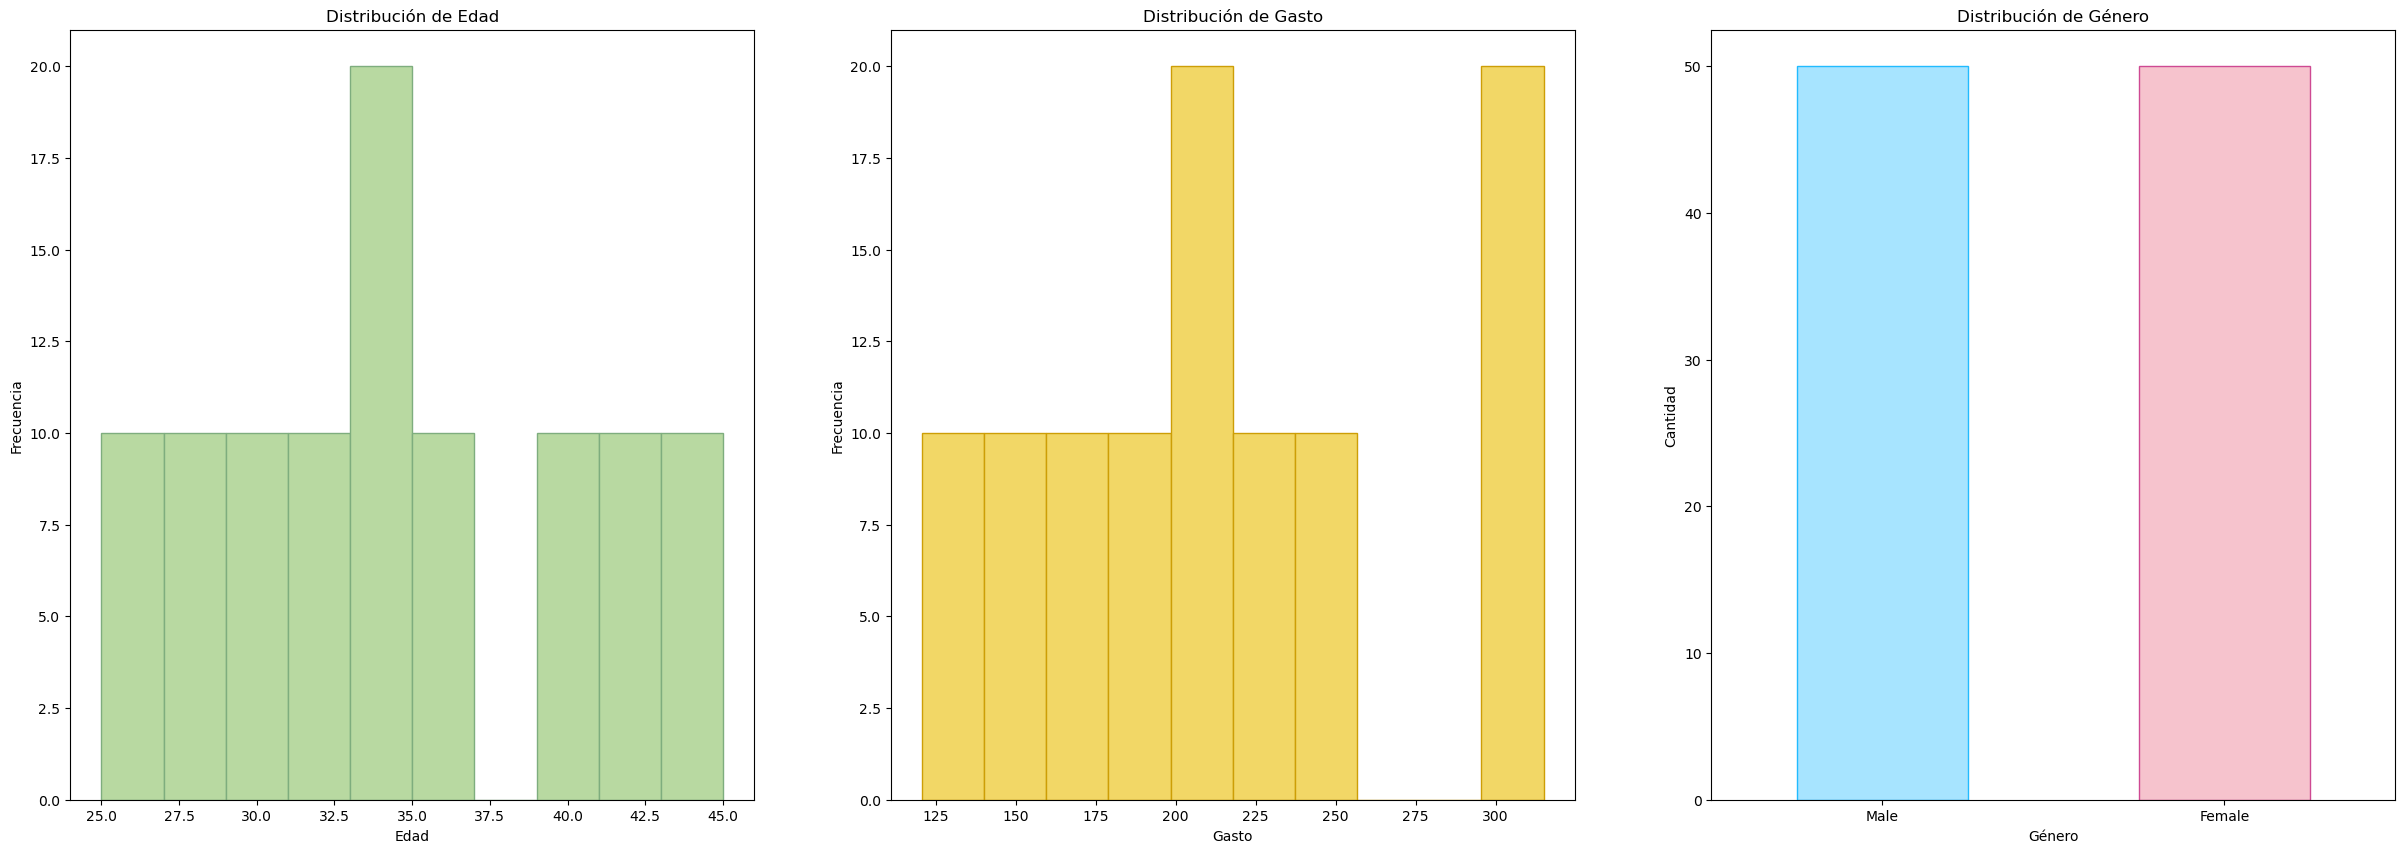

In [5]:
import matplotlib.pyplot as plt

# Variables a mostrar
edad = df["age"]
gasto = df["total_spent"]
genero = df["gender"].value_counts()

# Creación de la figura
plt.figure(figsize=(30,10))

# Gráfica 1: Edad
plt.subplot(131)
plt.hist(edad, color="#b8d9a1", ec="#7ead7e")
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

# Gráfica 2: Gasto
plt.subplot(132)
plt.hist(gasto, color="#f2d766", ec="#cd9e06")
plt.title("Distribución de Gasto")
plt.xlabel("Gasto")
plt.ylabel("Frecuencia")

# Gráfica 3: Género
plt.subplot(133)
genero.plot(kind="bar", color=["#a7e4ff", "#f6c3cd"], ec=["#22bbff", "#ce4993"])
plt.title("Distribución de Género")
plt.xlabel("Género")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)

**Interpretación de los Grágicos:**

|Edad: `age`|Gasto: `total_spent`|Género: `gender`|
|-----------|-----------|-----------|
|La distribución de la edad se presenta de forma relativamente uniforme dentro del rango observado, con una ligera concentración en edades cercanas a los 30–35 años. No se identifica una forma de campana pronunciada ni un sesgo evidente, lo que sugiere una dispersión homogénea de la variable.|El gasto total presenta variabilidad entre los clientes, con mayor presencia en rangos intermedios y algunos valores más altos. No se identifican valores atípicos extremos, lo que sugiere una distribución relativamente estable que puede aportar información relevante para diferenciar comportamientos de compra.|La distribución por género se encuentra balanceada, con proporciones similares entre hombres y mujeres, lo que evita sesgos en el análisis derivado de una representación desigual de esta variable.|

---
## 2. Tratamiento de los Datos
### 2.1. Preprocesamiento de las Variables
#### a. Verificación de valores nulos
Obtener el total de valores nulos de cada columna del DataFrame con los métodos `isnull()` y `sum()`.

In [6]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
total_spent                 0
frequency                   0
days_since_last_purchase    0
marketing_engaged           0
returned_next_month         0
dtype: int64

Se observa que todas las columnas presentan un **valor de 0**, lo que indica la **ausencia de datos faltantes** en el conjunto de datos. Por lo tanto, no es necesario aplicar técnicas de tratamiento o imputación. Este resultado es consistente con lo observado previamente mediante el método `info()`, el cual tampoco reporta valores nulos.

#### b. Codificación de variables categóricas
Mapear los valores de la variable género (`gender`) con valores legibles para los modelos.

In [7]:
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

Esto permite que los modelos puedan interpretar correctamente la variable, ya que estos no trabajan con datos en formato texto. Por ello, se asigna el valor **0** a la categoría `Female` y el valor **1** a la categoría `Male`, transformando la variable categórica en una representación numérica adecuada para el modelado.

#### c. Escalado de variables numéricas
Transformar las variables edad (`age`), total gastado (`total_spent`), frecuencia (`frequency`) y días desde la última compra (`days_since_last_purchase`) utilizando la librería `sklearn` y el método `fit_transform()`.

In [8]:
from sklearn.preprocessing import StandardScaler

escala = StandardScaler()
cols = ["age", "total_spent", "frequency", "days_since_last_purchase"]

df[cols] = escala.fit_transform(df[cols])

Este paso permite que todas las variables numéricas se encuentren en una escala comparable, transformándolas a una distribución con **media 0** y **desviación estándar 1**. De esta manera, se evita que el modelo se sesgue debido a diferencias en la magnitud de los valores, impidiendo que algunas variables tengan mayor peso únicamente por su escala y favoreciendo un proceso de entrenamiento más estable y equilibrado.  

### 2.2. División de Datos
#### a. Definición de Características
Definir la variable `X`, integrando todas las columnas excepto la variable objetivo.

In [9]:
X = df.drop('returned_next_month', axis=1)

#### b. Definición de Variable Objetivo
Definir la variable `y`, integrando la variable objetivo `returned_next_month`.

In [10]:
y = df['returned_next_month'] 

#### c. Separación de Datos de Entrenamiento y Prueba
Separar los datos utilizando la librería `sklearn` y el método `train_test_split()`.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mediante la función `train_test_split`, se separan las variables independientes `X` y la variable objetivo `y`, asignando un 80% de los datos para entrenamiento y un 20% para prueba. 

El conjunto de entrenamiento se utiliza para que el modelo aprenda los patrones presentes en los datos, mientras que el conjunto de prueba permite evaluar su desempeño en datos no vistos previamente.

Esta separación es fundamental para evitar sobreajuste y asegurar que el modelo tenga capacidad de generalización.

---
## 3. Entrenamiento de Modelos de Datos
### 3.1. Selección y Entrenamiento de Modelos
#### a. LogisticRegression
La regresión logística es un modelo de clasificación que permite establecer una base simple e interpretable, estimando la probabilidad de que una observación pertenezca a una de dos clases posibles.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Creación del modelo
regresion_log = LogisticRegression()

# Entrenamiento del modelo
regresion_log.fit(X_train, y_train)

# Prueba del modelo
pred_rlog = regresion_log.predict(X_test)

# Precisión del modelo
precision_rlog = accuracy_score(y_test, pred_rlog)
print(f"Precisión Regresión Logística: {precision_rlog*100:.2f}%", )

Precisión Regresión Logística: 100.00%


A partir de las **variables de entrada**, el modelo calcula una función que permite **predecir si un cliente regresará o no**, siendo especialmente útil por su simplicidad e interpretabilidad.  
Este modelo se toma como **referencia inicial** debido a su facilidad de implementación y a que permite interpretar de manera clara la relación entre las características y la variable objetivo.

#### b. DecisionTree
El árbol de decisión introduce relaciones no lineales mediante reglas jerárquicas basadas en las características de los datos. Este modelo divide el conjunto de datos en subconjuntos más pequeños.

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Creación del modelo
arbol = DecisionTreeClassifier()

# Entrenamiento del modelo
arbol.fit(X_train, y_train)

# Prueba del modelo
pred_arbol = arbol.predict(X_test)

# Precisión del modelo
precision_arbol = accuracy_score(y_test, pred_arbol)
print(f"Precisión Árbol de Decisiones: {precision_arbol*100:.2f}%", )


Precisión Árbol de Decisiones: 100.00%


Este modelo **genera las condiciones** que permiten **clasificar a los clientes** de forma intuitiva y fácil de interpretar. Al incluirlo, permite analizar **patrones más complejos** en los datos y **comparar su desempeño** frente a un modelo lineal como la regresión logística.

#### c. RandomForest
El bosque aleatorio mejora la capacidad predictiva al combinar múltiples árboles de decisión para aumentar la precisión de las predicciones. Cada árbol genera una predicción independiente y el resultado final se obtiene mediante votación, lo que permite reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Creación del modelo
bosque_rnd = RandomForestClassifier()

# Entrenamiento del modelo
bosque_rnd.fit(X_train, y_train)

# Prueba del modelo
pred_bosque = bosque_rnd.predict(X_test)

# Precisión del modelo
precision_bosque = accuracy_score(y_test, pred_bosque)
print(f"Precisión Bosque Aleatorio: {precision_bosque*100:.2f}%", )

Precisión Bosque Aleatorio: 100.00%


La selección de este modelo **permite evaluar un enfoque más robusto** y comparar su rendimiento **frente a modelos más simples**.

### 3.3. Análisis y Comparación de Modelos
Al realizar el entrenamiento y evaluación de los tres modelos seleccionados, se obtuvieron las siguientes métricas de precisión:    
<table style="width:100%; table-layout:fixed;">
  <tr>
      <th style="width:50%;">Modelo</th>
      <th style="width:50%;">Precisión</th>
  </tr>
  <tr><td style="text-align:center;">LogisticRegression</td>
      <td style="text-align:center;">100%</td>
  </tr>
  <tr><td style="text-align:center;">DecisionTree</td>
      <td style="text-align:center;">100%</td>
  </tr>
  <tr><td style="text-align:center;">RandomForest</td>
      <td style="text-align:center;">100%</td>
  </tr>
</table><br>

Dado que el conjunto de datos es relativamente pequeño y presenta patrones claros, los tres modelos logran aprender adecuadamente la relación entre las variables, obteniendo un desempeño idéntico en términos de precisión. Esto indica que no existe una diferencia significativa en el rendimiento entre los modelos evaluados bajo esta métrica.

Sin embargo, **los modelos basados en árboles**, como DecisionTree y RandomForest, **pueden ser más propensos al sobreajuste**, ya que tienden a ajustarse de forma muy específica a los datos de entrenamiento. Por esta razón, **se selecciona el modelo LogisticRegression** como modelo final, debido a su simplicidad, menor riesgo de sobreajuste y mayor interpretabilidad, lo cual facilita el análisis de la relación entre las variables y la variable objetivo.

### 3.4. Optimización del Modelo Elegido
Implementar la clase `GridSearchCV` de la librería `sklearn` con el objetivo de evaluar de manera sistemática diferentes configuraciones del modelo `LogisticRegression` y seleccionar automáticamente aquella que ofrece el mejor desempeño.

In [15]:
from sklearn.model_selection import GridSearchCV

# Definir los valores a probar
parametros = {
    # Controla qué tan complejo o flexible será el modelo.
    "C": [0.01, 0.1, 1, 10, 100] 
}

# División de los datos en 3 partes para validar el modelo.
gridSearchCV = GridSearchCV(LogisticRegression(), parametros, cv=3)

# Entrenmiento del modelo probando todos los valores de C.
gridSearchCV.fit(X_train, y_train)

# Valor con mejor desempeño
print("Mejor parámetro:", gridSearchCV.best_params_)

# Guarda el mejor modelo encontrado
modelo_optimizado = gridSearchCV.best_estimator_

# Realiza predicciones con el modelo optimizado
nva_prediccion = modelo_optimizado.predict(X_test)
nva_precision = accuracy_score(y_test, nva_prediccion)
print(f"Precisión Modelo Optimizado: {nva_precision*100:.2f}%", )

Mejor parámetro: {'C': 0.1}
Precisión Modelo Optimizado: 100.00%


Al realizar el proceso de optimización de hiperparámetros sobre el modelo LogisticRegression, se evaluaron distintos valores del parámetro C, el cual controla el equilibrio entre la complejidad del modelo y su capacidad de generalización.

Mediante el uso de GridSearchCV, se probaron diferentes configuraciones de manera sistemática y se seleccionó automáticamente el valor óptimo. Como resultado, se obtuvo el mejor desempeño con $C = 0.1$, lo que indica un modelo más simple, adecuado para evitar el sobreajuste y mantener una buena capacidad de generalización en este conjunto de datos.

Finalmente, el modelo fue reentrenado utilizando este valor óptimo y evaluado nuevamente, obteniendo una **precisión del 100%**.

### 3.5. Validación y Análisis de Errores
Validar la predicción del modelo utilizando la clase `confusion_matrix` de la librería `sklearn` y comparar los resultados contra los datos reales del conjunto de datos.

In [16]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, nva_prediccion)
print(matriz)

[[ 9  0]
 [ 0 11]]


La matriz de confusión muestra que el modelo clasifica correctamente todos los casos del conjunto de prueba.  

En particular, se identifican **9 verdaderos negativos**, correspondientes a clientes que no regresan y fueron correctamente clasificados, y **11 verdaderos positivos**, correspondientes a clientes que sí regresan y fueron correctamente identificados.

Asimismo, **no se presentan falsos positivos ni falsos negativos**, lo que implica que el modelo no comete errores de clasificación en este conjunto de datos.

Este resultado refleja un **desempeño perfecto del modelo en la predicción**; sin embargo, es importante considerar que este comportamiento puede estar influenciado por el tamaño reducido y la simplicidad del conjunto de datos, por lo que no necesariamente garantiza el mismo rendimiento en escenarios más complejos o con datos reales.

---
## 4. Conclusiones Finales
El proyecto permitió aplicar las principales fases del proceso de ciencia de datos, desde la exploración y preparación del conjunto de datos hasta la implementación y evaluación de modelos de clasificación. A partir de este proceso, se seleccionó el modelo de regresión logística como el más adecuado, obteniendo una precisión del 100% en el conjunto de prueba.

Con lo cual, se observa que **el modelo puede ser utilizado como una herramienta de apoyo para identificar clientes con baja probabilidad de retorno**, permitiendo implementar estrategias de retención más focalizadas, como promociones personalizadas, descuentos, recordatorios o campañas de seguimiento.

No obstante, es importante considerar que, **debido al tamaño y simplicidad del conjunto de datos, estos resultados no garantizan el mismo desempeño en escenarios reales**.